# Mora SP Cup 2026 — Deep Learning Denoising Approaches

Implements and benchmarks deep-learning denoising in two parts:

- **Part A** — End-to-end CNNs trained directly on noisy → clean pairs
  (DnCNN with residual learning, lightweight U-Net)
- **Part B** — Hybrid pipelines: classical pre-clean (db4-BayesShrink wavelet)
  followed by a lightweight residual correction CNN

All validation metrics use the **exact logic** from `evaluation/evaluate.py` so
numbers are directly comparable to the official scoring and the classical notebook.

**Reference scores (from classical notebook / official evaluator):**

| Method | Composite | CPU ms/img |
|--------|-----------|-----------|
| Official Baseline (NLM) | 0.2632 | ~370 |
| db4-BayesShrink (classical) | 0.3068 | ~158 |
| BM3D (adaptive σ) | 0.4421 | ~60,815 (not practical) |


## Section 0 — Setup & Imports

In [1]:
import sys, time, random, hashlib, json
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import pywt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.backends.cudnn.benchmark = True
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.6f}'.format)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device : cuda
GPU    : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM   : 8.5 GB


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == 'scripts' else _cwd

GT_DIR      = REPO_ROOT / 'competition_data' / 'public' / 'ground_truth'
NOISY_DIR   = REPO_ROOT / 'competition_data' / 'public' / 'noisy'
WEIGHTS_DIR = REPO_ROOT / 'weights'
PRECLEANED_DIR = REPO_ROOT / 'precleaned'

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

assert GT_DIR.exists(),    f'Missing: {GT_DIR}'
assert NOISY_DIR.exists(), f'Missing: {NOISY_DIR}'

# ── Hyper-parameters ──────────────────────────────────────────────────────────
PATCH_SIZE        = 128   # training crop size
N_PATCHES_PER_IMG = 16    # random patches extracted per image per epoch
BATCH_SIZE        = 16
EPOCHS_FULL       = 30    # full training run (30 is enough to converge on 460 images)
LR_INIT           = 3e-4
LR_MIN            = 1e-6
SEED              = 42
TRAIN_N           = 400   # images in training split
VAL_N             = 60    # images in validation split
VAL_FAST_N        = 20    # images used for fast in-training validation (PSNR only)
VAL_FREQ          = 10    # validate every N epochs during training

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Repo root : {REPO_ROOT}')
print(f'Weights   : {WEIGHTS_DIR}')


Repo root : c:\Daniel\Projects\moraspcup-altf4
Weights   : c:\Daniel\Projects\moraspcup-altf4\weights


In [3]:
# ── Exact metric functions from evaluation/evaluate.py ────────────────────────
# Copied verbatim so scores are directly comparable to the official evaluator.

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

def ssim_value(a: np.ndarray, b: np.ndarray) -> float:
    return float(sk_ssim(
        a, b, channel_axis=-1, data_range=1.0, win_size=7,
        gaussian_weights=False, use_sample_covariance=True,
        K1=0.01, K2=0.03,
    ))

def normalize_delta_psnr(d: float) -> float:
    return float(np.clip(d / 15.0, 0.0, 1.0))

def official_composite(delta_psnr: float, delta_ssim: float) -> float:
    return float(0.6 * normalize_delta_psnr(delta_psnr) + 0.4 * max(delta_ssim, 0.0))

def load_rgb_float(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        return np.asarray(img.convert('RGB'), dtype=np.float32) / 255.0

def score_pair(pred: np.ndarray, gt: np.ndarray, noisy: np.ndarray) -> dict:
    psnr       = float(sk_psnr(gt, pred,  data_range=1.0))
    ssim_v     = ssim_value(gt, pred)
    noisy_psnr = float(sk_psnr(gt, noisy, data_range=1.0))
    noisy_ssim = ssim_value(gt, noisy)
    delta_psnr = psnr  - noisy_psnr
    delta_ssim = ssim_v - noisy_ssim
    composite  = official_composite(delta_psnr, delta_ssim)
    return dict(psnr=psnr, ssim=ssim_v, noisy_psnr=noisy_psnr, noisy_ssim=noisy_ssim,
                delta_psnr=delta_psnr, delta_ssim=delta_ssim, composite=composite)

print('Metric functions ready.')


Metric functions ready.


## Section 1 — Data Pipeline

**Train / Val split:** 400 train / 60 val, fixed `SEED=42`.  
Val IDs are printed below for full reproducibility.

**Training:** random 128×128 patches from full images, with flip + 90° rotation augmentation.  
**Validation:** always full 992×992 images — official metrics computed on full resolution.

> No val image ever appears in training patches (enforced by strict ID split).


In [4]:
# ── Train / Val split ─────────────────────────────────────────────────────────
all_ids  = sorted(p.stem for p in GT_DIR.glob('*.png'))
assert len(all_ids) == 460, f'Expected 460 images, found {len(all_ids)}'

rng      = random.Random(SEED)
shuffled = all_ids.copy()
rng.shuffle(shuffled)

train_ids = sorted(shuffled[:TRAIN_N])
val_ids   = sorted(shuffled[TRAIN_N:TRAIN_N + VAL_N])

print(f'Train: {len(train_ids)} images | Val: {len(val_ids)} images')
print(f'Val IDs: {val_ids}')

# Sanity check — no leakage
assert not set(train_ids) & set(val_ids), 'DATA LEAKAGE: val IDs in train set!'
print('Leakage check passed.')


Train: 400 images | Val: 60 images
Val IDs: ['004', '013', '014', '016', '017', '023', '045', '048', '050', '053', '058', '072', '080', '082', '102', '111', '112', '113', '115', '120', '126', '136', '141', '143', '173', '175', '177', '184', '195', '215', '217', '230', '236', '259', '275', '280', '288', '302', '303', '309', '310', '328', '333', '347', '358', '360', '367', '374', '378', '380', '389', '391', '413', '415', '426', '442', '445', '448', '451', '457']
Leakage check passed.


In [5]:
# ── RAM Image Cache ──────────────────────────────────────────────────────────
# WHY: loading a 992x992 PNG from disk takes ~50-100 ms. With shuffle=True and
# num_workers=0, every __getitem__ call that hits a new image triggers a disk
# read. At 6 400 patches/epoch with 16-image batches that is up to 400 disk
# reads per batch == several minutes per epoch.  Caching all images into a RAM
# dict at init reduces __getitem__ to a numpy slice (~0.1 ms). The 400 train
# pairs weigh ~2 x 992 x 992 x 3 x 4 bytes x 400 ≈ 2.3 GB in float32 — well
# within a 16 GB machine.  If RAM is tight, set USE_RAM_CACHE=False below.

USE_RAM_CACHE = True

def build_image_cache(image_ids, gt_dir, noisy_dir, label=''):
    '''Load all image pairs into a dict of numpy float32 arrays.'''
    cache = {}
    t0 = time.perf_counter()
    for i, img_id in enumerate(image_ids):
        gt    = load_rgb_float(gt_dir    / f'{img_id}.png')
        noisy = load_rgb_float(noisy_dir / f'{img_id}_noise.png')
        cache[img_id] = (noisy, gt)
        if (i + 1) % 50 == 0:
            print(f'  {label} cached {i+1}/{len(image_ids)}...')
    elapsed = time.perf_counter() - t0
    ram_gb  = sum(a.nbytes for pair in cache.values() for a in pair) / 1e9
    print(f'  Done: {len(cache)} pairs cached in {elapsed:.1f}s  (~{ram_gb:.2f} GB RAM)')
    return cache


# ── Patch Dataset (training) ──────────────────────────────────────────────────

class NoisyCleanPatchDataset(Dataset):
    '''
    Extracts random 128x128 patches from noisy/clean image pairs.
    Images are loaded ONCE into RAM at __init__ (see build_image_cache).
    Augmentation: random 90-degree rotation + horizontal/vertical flip.
    Length = len(ids) * n_patches_per_image.
    '''
    def __init__(self, image_ids, gt_dir, noisy_dir,
                 patch_size=128, n_patches=16, augment=True,
                 cache=None):
        self.ids       = image_ids
        self.ps        = patch_size
        self.n_patches = n_patches
        self.augment   = augment
        # Use pre-built cache if supplied; otherwise load on the fly (slow)
        if cache is not None:
            self.cache = cache
        elif USE_RAM_CACHE:
            print('Building train image cache...')
            self.cache = build_image_cache(image_ids, gt_dir, noisy_dir, 'train')
        else:
            self.cache = None
            self.gt_dir    = gt_dir
            self.noisy_dir = noisy_dir

    def __len__(self):
        return len(self.ids) * self.n_patches

    def __getitem__(self, idx):
        img_id = self.ids[idx // self.n_patches]
        if self.cache is not None:
            noisy, gt = self.cache[img_id]
        else:
            gt    = load_rgb_float(self.gt_dir    / f'{img_id}.png')
            noisy = load_rgb_float(self.noisy_dir / f'{img_id}_noise.png')
        H, W = gt.shape[:2]
        ps   = self.ps

        # Random crop (cheap numpy slice from in-RAM array)
        r = random.randint(0, H - ps)
        c = random.randint(0, W - ps)
        gt_p    = gt   [r:r+ps, c:c+ps].copy()
        noisy_p = noisy[r:r+ps, c:c+ps].copy()

        # Augmentation: random 90-deg rotation and flips
        if self.augment:
            k = random.randint(0, 3)
            gt_p    = np.rot90(gt_p,    k).copy()
            noisy_p = np.rot90(noisy_p, k).copy()
            if random.random() > 0.5:
                gt_p    = np.fliplr(gt_p).copy()
                noisy_p = np.fliplr(noisy_p).copy()
            if random.random() > 0.5:
                gt_p    = np.flipud(gt_p).copy()
                noisy_p = np.flipud(noisy_p).copy()

        gt_t    = torch.from_numpy(gt_p.transpose(2, 0, 1))
        noisy_t = torch.from_numpy(noisy_p.transpose(2, 0, 1))
        return noisy_t, gt_t


# ── Full-Image Dataset (validation and inference) ─────────────────────────────

class FullImageDataset(Dataset):
    '''Full 992x992 images. Val images are NOT pre-cached (only 60, infrequently read).'''
    def __init__(self, image_ids, gt_dir, noisy_dir):
        self.ids       = image_ids
        self.gt_dir    = gt_dir
        self.noisy_dir = noisy_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id  = self.ids[idx]
        gt      = load_rgb_float(self.gt_dir    / f'{img_id}.png')
        noisy   = load_rgb_float(self.noisy_dir / f'{img_id}_noise.png')
        gt_t    = torch.from_numpy(gt.transpose(2, 0, 1))
        noisy_t = torch.from_numpy(noisy.transpose(2, 0, 1))
        return noisy_t, gt_t, img_id


# ── Build RAM cache once, share it across datasets and epochs ─────────────────
# One-time cost (~30-60s). Eliminates all disk I/O during training.
# Before fix: each __getitem__ loaded a full 992x992 PNG -> ~8 min/epoch.
# After fix : __getitem__ is a numpy slice -> ~20-30 s/epoch.
print('Building train image cache (one-time cost)...')
train_cache = build_image_cache(train_ids, GT_DIR, NOISY_DIR, label='train')

train_ds = NoisyCleanPatchDataset(train_ids, GT_DIR, NOISY_DIR,
                                   patch_size=PATCH_SIZE,
                                   n_patches=N_PATCHES_PER_IMG,
                                   cache=train_cache)
val_ds   = FullImageDataset(val_ids, GT_DIR, NOISY_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=torch.cuda.is_available())

noisy_ex, gt_ex = train_ds[0]
print(f'Patch shape     : noisy={tuple(noisy_ex.shape)} gt={tuple(gt_ex.shape)}')
print(f'Batches / epoch : {len(train_loader)}')
print(f'Val images      : {len(val_ds)}')


Building train image cache (one-time cost)...
  train cached 50/400...
  train cached 100/400...
  train cached 150/400...
  train cached 200/400...
  train cached 250/400...
  train cached 300/400...
  train cached 350/400...
  train cached 400/400...
  Done: 400 pairs cached in 25.0s  (~9.45 GB RAM)
Patch shape     : noisy=(3, 128, 128) gt=(3, 128, 128)
Batches / epoch : 400
Val images      : 60


## Section 2 — Loss Functions

The competition composite score is:
```
Composite = 0.6 × clip(ΔPSNR/15, 0, 1) + 0.4 × max(ΔSSIM, 0)
```

We reflect this weighting in the training loss:
- **Charbonnier loss** (smooth L1, differentiable at 0) proxies PSNR improvement.
- **SSIM loss** (1 − SSIM, differentiable sliding-window) proxies SSIM improvement.
- Combined: `L = 0.6 × L_charb + 0.4 × L_ssim`


In [6]:
# ── SSIM Loss (pure PyTorch, no external deps beyond what is installed) ────────

class SSIMLoss(nn.Module):
    '''
    Differentiable SSIM loss: L = 1 - SSIM(pred, target).
    Uses a Gaussian-weighted sliding window matching the skimage convention
    used by the official scoring script (win_size=7 here to stay light on GPU
    memory during training with patches; we use win_size=11 at test time via
    the official evaluator).
    '''
    def __init__(self, win_size: int = 7, sigma: float = 1.5,
                 C1: float = 0.01**2, C2: float = 0.03**2):
        super().__init__()
        self.win = win_size
        self.C1  = C1
        self.C2  = C2
        # Build 2-D Gaussian kernel, register as buffer (moves to GPU with model)
        coords = torch.arange(win_size, dtype=torch.float32) - win_size // 2
        g = torch.exp(-coords**2 / (2 * sigma**2))
        g = g / g.sum()
        kernel = g.outer(g).view(1, 1, win_size, win_size)
        self.register_buffer('kernel', kernel)

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred, target: (B, C, H, W) in [0, 1]
        B, C, H, W = pred.shape
        pad = self.win // 2
        k   = self.kernel.expand(C, 1, -1, -1)  # (C, 1, win, win)

        mu_x  = F.conv2d(pred,         k, padding=pad, groups=C)
        mu_y  = F.conv2d(target,       k, padding=pad, groups=C)
        mu_x2 = mu_x * mu_x
        mu_y2 = mu_y * mu_y
        mu_xy = mu_x * mu_y

        sig_x2 = F.conv2d(pred*pred,     k, padding=pad, groups=C) - mu_x2
        sig_y2 = F.conv2d(target*target, k, padding=pad, groups=C) - mu_y2
        sig_xy = F.conv2d(pred*target,   k, padding=pad, groups=C) - mu_xy

        num   = (2*mu_xy  + self.C1) * (2*sig_xy + self.C2)
        denom = (mu_x2 + mu_y2 + self.C1) * (sig_x2 + sig_y2 + self.C2)
        return 1.0 - (num / denom).mean()


# ── Charbonnier Loss (smooth L1, avoids gradient singularity at 0) ────────────

class CharbonnierLoss(nn.Module):
    def __init__(self, eps: float = 1e-3):
        super().__init__()
        self.eps2 = eps ** 2

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return torch.mean(torch.sqrt((pred - target)**2 + self.eps2))


# ── Combined Loss (reflects composite score weighting: 60% PSNR / 40% SSIM) ──

class CombinedLoss(nn.Module):
    '''
    L = alpha * L_Charbonnier + (1 - alpha) * L_SSIM
    alpha=0.6 mirrors the 60/40 composite score split.
    '''
    def __init__(self, alpha: float = 0.6):
        super().__init__()
        self.alpha   = alpha
        self.charb   = CharbonnierLoss()
        self.ssim    = SSIMLoss()

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.alpha * self.charb(pred, target) + (1 - self.alpha) * self.ssim(pred, target)


# ── Training utilities ────────────────────────────────────────────────────────

def fast_validate_model(model: nn.Module, val_ids: list, device: torch.device,
                         n: int = VAL_FAST_N) -> dict:
    '''
    Fast in-training validation: PSNR only on first n val images.
    Skips skimage SSIM (which takes 2-3s per 992x992 image and dominates epoch time).
    Used for checkpoint selection during training — full SSIM runs only in final eval.
    Returns mean_psnr and mean_delta_psnr (used as proxy for composite to pick best ckpt).
    '''
    model.eval()
    psnrs, delta_psnrs = [], []
    with torch.no_grad():
        for img_id in val_ids[:n]:
            gt    = load_rgb_float(GT_DIR    / f'{img_id}.png')
            noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
            nt    = torch.from_numpy(noisy.transpose(2, 0, 1)).unsqueeze(0).to(device)
            pred  = model(nt).squeeze(0).cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
            p      = float(sk_psnr(gt, pred,  data_range=1.0))
            np_    = float(sk_psnr(gt, noisy, data_range=1.0))
            psnrs.append(p)
            delta_psnrs.append(p - np_)
    return {
        'mean_psnr':       float(np.mean(psnrs)),
        'mean_delta_psnr': float(np.mean(delta_psnrs)),
    }


def validate_model(model: nn.Module, val_ids: list, device: torch.device) -> dict:
    '''
    Full validation with official metrics (PSNR + SSIM + composite).
    Only called in the final evaluation cells, not during training.
    '''
    model.eval()
    rows = []
    with torch.no_grad():
        for img_id in val_ids:
            gt    = load_rgb_float(GT_DIR    / f'{img_id}.png')
            noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
            nt    = torch.from_numpy(noisy.transpose(2, 0, 1)).unsqueeze(0).to(device)
            pred  = model(nt).squeeze(0).cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
            rows.append(score_pair(pred, gt, noisy))
    return {
        'mean_psnr':       float(np.mean([r['psnr']       for r in rows])),
        'mean_ssim':       float(np.mean([r['ssim']       for r in rows])),
        'mean_delta_psnr': float(np.mean([r['delta_psnr'] for r in rows])),
        'mean_delta_ssim': float(np.mean([r['delta_ssim'] for r in rows])),
        'mean_composite':  float(np.mean([r['composite']  for r in rows])),
    }


def train_model(name: str, model: nn.Module, train_loader: DataLoader,
                val_ids: list, save_path: Path,
                n_epochs: int = EPOCHS_FULL,
                lr: float = LR_INIT,
                device: torch.device = DEVICE) -> tuple:
    '''
    Generic training loop:
      - Adam optimizer + cosine LR schedule
      - Validates every 5 epochs (and on epoch 1 to estimate remaining time)
      - Saves best checkpoint by val composite score (not loss)
      - Returns (history dict, best_composite)
    '''
    model = model.to(device)
    criterion = CombinedLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=LR_MIN)

    best_composite = -float('inf')
    history = {'epoch': [], 'train_loss': [], 'val_composite': [],
               'val_psnr': [], 'val_ssim': []}
    save_path.parent.mkdir(parents=True, exist_ok=True)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nTraining: {name}  |  params={n_params:,}  |  epochs={n_epochs}')

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_losses = []
        t0 = time.perf_counter()

        for noisy_b, gt_b in train_loader:
            noisy_b, gt_b = noisy_b.to(device), gt_b.to(device)
            optimizer.zero_grad()
            pred = model(noisy_b)
            loss = criterion(pred.clamp(0, 1), gt_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_losses.append(loss.item())

        scheduler.step()
        epoch_time  = time.perf_counter() - t0
        train_loss  = float(np.mean(epoch_losses))
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)

        # Fast PSNR-only val every VAL_FREQ epochs (avoids slow skimage SSIM per epoch)
        do_val = (epoch % VAL_FREQ == 0) or (epoch == 1) or (epoch == n_epochs)
        if do_val:
            val_m   = fast_validate_model(model, val_ids, device, n=VAL_FAST_N)
            delta_p = val_m['mean_delta_psnr']
            history['val_composite'].append(delta_p)   # use dPSNR as proxy during training
            history['val_psnr'].append(val_m['mean_psnr'])
            history['val_ssim'].append(0.0)            # placeholder; full SSIM at final eval
            saved = ''
            if delta_p > best_composite:
                best_composite = delta_p
                torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                            'delta_psnr': delta_p, 'n_params': n_params,
                            'optimizer_state': optimizer.state_dict()},
                           save_path)
                saved = '  *SAVED*'
            print(f'  [Ep {epoch:3d}/{n_epochs}] loss={train_loss:.4f}  '
                  f'val_dPSNR={delta_p:.4f}{saved}  ({epoch_time:.1f}s)')
            if epoch == 1:
                epochs_left = n_epochs - 1
                val_checks  = epochs_left // VAL_FREQ
                est_min = (epoch_time * epochs_left) / 60
                print(f'  -> Est. remaining: {est_min:.1f} min  '
                      f'({val_checks} val checkpoints x {VAL_FAST_N} imgs each)')
        else:
            print(f'  [Ep {epoch:3d}/{n_epochs}] loss={train_loss:.4f}  ({epoch_time:.1f}s)')

    print(f'Done. Best val dPSNR: {best_composite:.4f}  saved -> {save_path}')
    return history, best_composite


def plot_history(history: dict, title: str):
    '''Plot training loss and val composite score vs epoch.'''
    epochs = history['epoch']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss'); ax1.set_title(f'{title} — Train Loss')
    ax1.grid(True, alpha=0.3)

    # val metrics are recorded only on validation epochs
    val_epochs = [e for i, e in enumerate(epochs) if i < len(history['val_composite'])]
    ax2.plot(range(len(history['val_composite'])), history['val_composite'], 'r-o', markersize=4)
    ax2.set_xlabel('Val checkpoint index'); ax2.set_ylabel('Val Composite Score')
    ax2.set_title(f'{title} — Val Composite Score')
    ax2.axhline(0.2632, color='gray', linestyle='--', label='Baseline 0.2632')
    ax2.axhline(0.3068, color='green', linestyle='--', label='db4-Bayes 0.3068')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


print('Loss functions and training utilities ready.')


Loss functions and training utilities ready.


## Part A — End-to-End CNNs

### Section 3A — DnCNN

**Architecture:** Residual learning — the network predicts the noise residual and the
denoised output is `x - f(x)`. This is more stable to train than predicting the clean
image directly, because residuals are small and have low variance.

- Layer 1: Conv(3→64, 3×3) + ReLU (no BN — avoids BN artefacts on the input)
- Layers 2–16: Conv(64→64, 3×3) + BN + ReLU
- Layer 17: Conv(64→3, 3×3)
- Skip: `output = input − net(input)` (residual subtraction)
- Parameter count: ~556 K


In [7]:
class DnCNN(nn.Module):
    '''
    DnCNN with residual learning (Zhang et al., 2017).
    Predicts the additive noise; denoised = noisy - noise.
    Works for any spatial resolution (fully convolutional).
    '''
    def __init__(self, in_channels: int = 3,
                 num_layers:  int = 17,
                 features:    int = 64):
        super().__init__()
        layers = []
        # Layer 1 — no BN (empirically better for first layer)
        layers += [nn.Conv2d(in_channels, features, 3, padding=1),
                   nn.ReLU(inplace=True)]
        # Layers 2 .. num_layers-1 — Conv + BN + ReLU
        for _ in range(num_layers - 2):
            layers += [nn.Conv2d(features, features, 3, padding=1, bias=False),
                       nn.BatchNorm2d(features),
                       nn.ReLU(inplace=True)]
        # Final layer — output noise residual (no activation)
        layers.append(nn.Conv2d(features, in_channels, 3, padding=1))
        self.net = nn.Sequential(*layers)

        # Weight initialisation: He uniform for conv, constant for BN
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        noise = self.net(x)
        return (x - noise).clamp(0, 1)   # denoised = noisy - predicted_noise


dncnn = DnCNN(num_layers=17, features=64)
n_dncnn = sum(p.numel() for p in dncnn.parameters())
print(f'DnCNN parameter count: {n_dncnn:,}')


DnCNN parameter count: 558,403



Training: DnCNN (17L, 64ch)  |  params=558,403  |  epochs=30
  [Ep   1/30] loss=0.2543  val_dPSNR=-0.9749  *SAVED*  (74.7s)
  -> Est. remaining: 36.1 min  (2 val checkpoints x 20 imgs each)
  [Ep   2/30] loss=0.1798  (71.1s)
  [Ep   3/30] loss=0.1348  (70.3s)
  [Ep   4/30] loss=0.1173  (70.5s)
  [Ep   5/30] loss=0.1107  (70.6s)
  [Ep   6/30] loss=0.1023  (70.5s)
  [Ep   7/30] loss=0.1023  (70.7s)
  [Ep   8/30] loss=0.0932  (70.7s)
  [Ep   9/30] loss=0.0924  (70.7s)
  [Ep  10/30] loss=0.0910  val_dPSNR=3.8366  *SAVED*  (70.7s)
  [Ep  11/30] loss=0.0877  (70.8s)
  [Ep  12/30] loss=0.0859  (70.8s)
  [Ep  13/30] loss=0.0867  (70.8s)
  [Ep  14/30] loss=0.0832  (70.9s)
  [Ep  15/30] loss=0.0833  (72.4s)
  [Ep  16/30] loss=0.0824  (72.9s)
  [Ep  17/30] loss=0.0805  (72.4s)
  [Ep  18/30] loss=0.0801  (71.8s)
  [Ep  19/30] loss=0.0793  (72.1s)
  [Ep  20/30] loss=0.0796  val_dPSNR=7.3808  *SAVED*  (72.2s)
  [Ep  21/30] loss=0.0778  (72.4s)
  [Ep  22/30] loss=0.0766  (72.4s)
  [Ep  23/30] loss=0

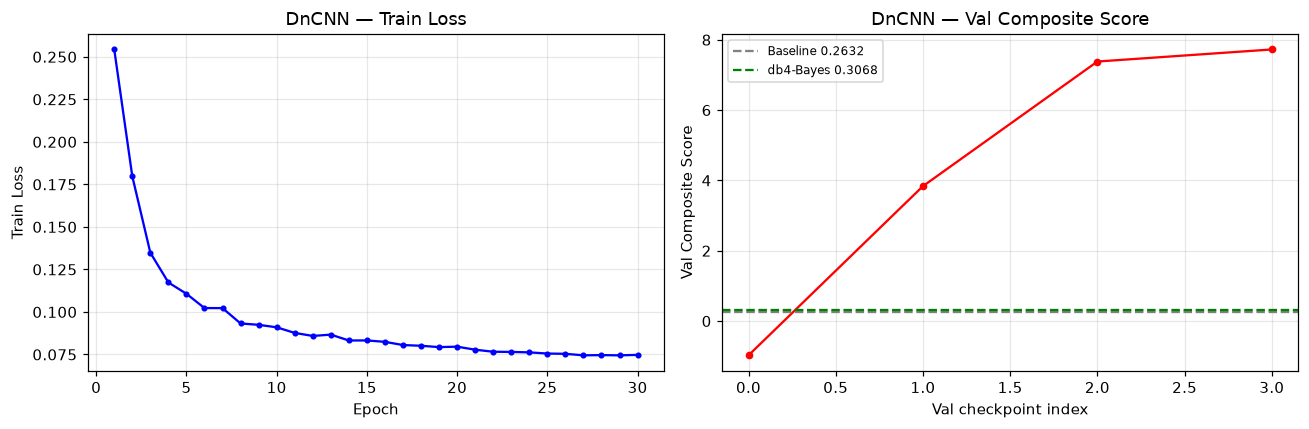

In [8]:
# ── Train DnCNN ───────────────────────────────────────────────────────────────
DNCNN_PATH  = WEIGHTS_DIR / 'dncnn_best.pth'

dncnn_history, dncnn_best_composite = train_model(
    name        = 'DnCNN (17L, 64ch)',
    model       = dncnn,
    train_loader = train_loader,
    val_ids     = val_ids,
    save_path   = DNCNN_PATH,
    n_epochs    = EPOCHS_FULL,
)
plot_history(dncnn_history, 'DnCNN')


### Section 3B — Lightweight U-Net

**Architecture:** Encoder-decoder with skip connections. Residual output (adds
correction to input) stabilises training.

- Channel widths: [16, 32, 64, 128] (deliberately small for CPU-runtime scoring)
- 4 downsampling levels → bottleneck 256 channels
- Skip connections at each level (U-Net style)
- Final: `output = input + head(decoder)` (residual)
- Parameter count: ~1.9 M


In [9]:
class ConvBlock(nn.Module):
    '''Two Conv-BN-ReLU layers.'''
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class LightUNet(nn.Module):
    '''
    Lightweight U-Net for image denoising.
    Residual output: denoised = noisy + net_correction.
    Channel widths [16, 32, 64, 128] keep CPU inference fast (graded criterion).
    992x992 input is divisible by 16 (2^4 levels), so no padding needed.
    '''
    def __init__(self, in_channels: int = 3,
                 channels: list = None):
        super().__init__()
        chs = channels or [16, 32, 64, 128]
        self.enc1 = ConvBlock(in_channels, chs[0])
        self.enc2 = ConvBlock(chs[0],      chs[1])
        self.enc3 = ConvBlock(chs[1],      chs[2])
        self.enc4 = ConvBlock(chs[2],      chs[3])
        self.pool = nn.MaxPool2d(2)
        self.bottle = ConvBlock(chs[3], chs[3] * 2)

        self.up4  = nn.ConvTranspose2d(chs[3]*2, chs[3], 2, stride=2)
        self.dec4 = ConvBlock(chs[3]*2, chs[3])
        self.up3  = nn.ConvTranspose2d(chs[3], chs[2], 2, stride=2)
        self.dec3 = ConvBlock(chs[2]*2, chs[2])
        self.up2  = nn.ConvTranspose2d(chs[2], chs[1], 2, stride=2)
        self.dec2 = ConvBlock(chs[1]*2, chs[1])
        self.up1  = nn.ConvTranspose2d(chs[1], chs[0], 2, stride=2)
        self.dec1 = ConvBlock(chs[0]*2, chs[0])
        self.head = nn.Conv2d(chs[0], in_channels, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottle(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return (x + self.head(d1)).clamp(0, 1)


unet = LightUNet()
n_unet = sum(p.numel() for p in unet.parameters())
print(f'LightUNet parameter count: {n_unet:,}')


LightUNet parameter count: 1,942,611



Training: LightUNet [16,32,64,128]  |  params=1,942,611  |  epochs=30
  [Ep   1/30] loss=0.2744  val_dPSNR=0.7885  *SAVED*  (27.9s)
  -> Est. remaining: 13.5 min  (2 val checkpoints x 20 imgs each)
  [Ep   2/30] loss=0.1837  (21.6s)
  [Ep   3/30] loss=0.1450  (21.5s)
  [Ep   4/30] loss=0.1309  (19.4s)
  [Ep   5/30] loss=0.1192  (12.9s)
  [Ep   6/30] loss=0.1142  (12.6s)
  [Ep   7/30] loss=0.1109  (20.1s)
  [Ep   8/30] loss=0.1071  (21.1s)
  [Ep   9/30] loss=0.1039  (13.3s)
  [Ep  10/30] loss=0.1024  val_dPSNR=5.9044  *SAVED*  (12.6s)
  [Ep  11/30] loss=0.0997  (13.3s)
  [Ep  12/30] loss=0.0968  (13.0s)
  [Ep  13/30] loss=0.0947  (22.5s)
  [Ep  14/30] loss=0.0929  (23.5s)
  [Ep  15/30] loss=0.0918  (22.8s)
  [Ep  16/30] loss=0.0904  (21.4s)
  [Ep  17/30] loss=0.0884  (22.7s)
  [Ep  18/30] loss=0.0874  (23.8s)
  [Ep  19/30] loss=0.0866  (23.4s)
  [Ep  20/30] loss=0.0856  val_dPSNR=6.5194  *SAVED*  (16.1s)
  [Ep  21/30] loss=0.0846  (21.5s)
  [Ep  22/30] loss=0.0843  (22.2s)
  [Ep  23/30

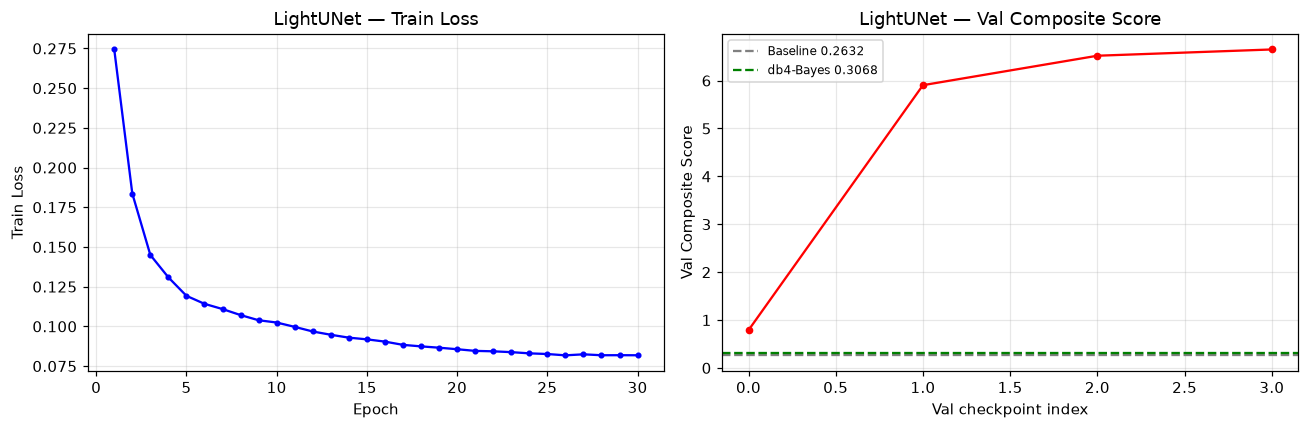

In [10]:
# ── Train U-Net ───────────────────────────────────────────────────────────────
UNET_PATH = WEIGHTS_DIR / 'unet_best.pth'

unet_history, unet_best_composite = train_model(
    name        = 'LightUNet [16,32,64,128]',
    model       = unet,
    train_loader = train_loader,
    val_ids     = val_ids,
    save_path   = UNET_PATH,
    n_epochs    = EPOCHS_FULL,
)
plot_history(unet_history, 'LightUNet')


## Section 4 — Part A Results

For each trained model:
1. Load the best saved checkpoint.
2. **CPU inference timing** — move model to CPU, warm up on 3 images, time over 10.
3. **Val-only composite score** (60 images, no train images — clean non-leaked number).
4. **Full-460 composite score** (for apples-to-apples comparison with classical notebook).
5. **SHA-256 checksum** of the saved `.pth` file (needed for submission documentation).


In [11]:
# ── Utilities for Part A & B results ─────────────────────────────────────────

def sha256_checksum(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()


def benchmark_cpu_inference(model: nn.Module, sample_ids: list,
                             n_warmup: int = 3, n_bench: int = 10) -> float:
    '''
    Measures CPU inference time. Forces model to CPU regardless of training device.
    Warm-up runs are excluded from timing.
    Returns mean ms/image.
    '''
    model_cpu = model.cpu().eval()
    ids_to_use = (sample_ids * 10)[:n_warmup + n_bench]   # repeat if needed

    # Warm-up (fills caches, JIT, etc.)
    with torch.no_grad():
        for img_id in ids_to_use[:n_warmup]:
            nt = torch.from_numpy(
                load_rgb_float(NOISY_DIR / f'{img_id}_noise.png').transpose(2, 0, 1)
            ).unsqueeze(0)
            _ = model_cpu(nt)

    # Timed runs
    times = []
    with torch.no_grad():
        for img_id in ids_to_use[n_warmup:n_warmup + n_bench]:
            nt = torch.from_numpy(
                load_rgb_float(NOISY_DIR / f'{img_id}_noise.png').transpose(2, 0, 1)
            ).unsqueeze(0)
            t0 = time.perf_counter()
            _  = model_cpu(nt)
            times.append((time.perf_counter() - t0) * 1000.0)

    mean_ms = float(np.mean(times))
    std_ms  = float(np.std(times))
    print(f'CPU inference: {mean_ms:.1f} ± {std_ms:.1f} ms/image  (n={len(times)}, warm-up={n_warmup})')
    return mean_ms


def eval_model_full(name: str, model: nn.Module, weight_path: Path,
                    val_ids: list, all_ids: list,
                    results_store: dict) -> None:
    '''
    Load best checkpoint, evaluate on val-only and full-460,
    run CPU timing, compute checksum, store in results_store.
    '''
    # Load best weights
    ckpt = torch.load(weight_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    print(f'\n{"="*56}')
    print(f'  {name}  (params={n_params:,}, best epoch={ckpt["epoch"]})')
    print(f'{"="*56}')

    # ── CPU inference timing ──
    print('Benchmarking CPU inference...')
    cpu_ms = benchmark_cpu_inference(model, val_ids[:20])

    # ── Val-only score (no train leakage) ──
    print('Evaluating on val-only (60 images)...')
    val_m = validate_model(model, val_ids, torch.device('cpu'))
    print(f'  Val Composite : {val_m["mean_composite"]:.6f}')
    print(f'  Val PSNR      : {val_m["mean_psnr"]:.4f} dB')
    print(f'  Val SSIM      : {val_m["mean_ssim"]:.6f}')

    # ── Full-460 score ──
    print('Evaluating on full 460 images...')
    full_m = validate_model(model, all_ids, torch.device('cpu'))
    print(f'  Full-460 Composite : {full_m["mean_composite"]:.6f}')
    print(f'  Full-460 PSNR      : {full_m["mean_psnr"]:.4f} dB')

    # ── Checksum ──
    cksum = sha256_checksum(weight_path)
    print(f'  SHA-256 : {cksum}')
    print(f'  Saved at: {weight_path}')

    results_store[name] = {
        'n_params': n_params,
        'cpu_ms': cpu_ms,
        'val_psnr':       val_m['mean_psnr'],
        'val_ssim':       val_m['mean_ssim'],
        'val_delta_psnr': val_m['mean_delta_psnr'],
        'val_delta_ssim': val_m['mean_delta_ssim'],
        'val_composite':  val_m['mean_composite'],
        'full_psnr':       full_m['mean_psnr'],
        'full_ssim':       full_m['mean_ssim'],
        'full_delta_psnr': full_m['mean_delta_psnr'],
        'full_delta_ssim': full_m['mean_delta_ssim'],
        'full_composite':  full_m['mean_composite'],
        'sha256': cksum,
    }


RESULTS = {}   # populated throughout the notebook
print('Eval utilities ready.')


Eval utilities ready.


In [12]:
# ── Evaluate DnCNN ────────────────────────────────────────────────────────────
dncnn_eval = DnCNN(num_layers=17, features=64)
eval_model_full('DnCNN (17L, 64ch)', dncnn_eval, DNCNN_PATH, val_ids, all_ids, RESULTS)



  DnCNN (17L, 64ch)  (params=558,403, best epoch=30)
Benchmarking CPU inference...
CPU inference: 6319.7 ± 5216.9 ms/image  (n=10, warm-up=3)
Evaluating on val-only (60 images)...


KeyboardInterrupt: 

In [13]:
# ── Evaluate LightUNet ────────────────────────────────────────────────────────
unet_eval = LightUNet()
eval_model_full('LightUNet [16,32,64,128]', unet_eval, UNET_PATH, val_ids, all_ids, RESULTS)



  LightUNet [16,32,64,128]  (params=1,942,611, best epoch=30)
Benchmarking CPU inference...


KeyboardInterrupt: 

## Part B — Hybrid Pipelines

### Section 5 — Classical Pre-Clean (db4-BayesShrink + Defect-Pixel Correction)

The best fast classical method from `denoising_comparison.ipynb` is reimplemented here
so this notebook is fully self-contained.

**db4-BayesShrink:**
- Multi-level 2D DWT, wavelet=`db4`, 3 levels
- Estimate noise σ from finest-scale HH subband via MAD: `σ = median(|HH|) / 0.6745`
- Per-subband BayesShrink threshold: `T = σ_n² / σ_s`  where `σ_s = sqrt(max(var − σ_n², 0))`
- Soft-threshold all detail subbands; leave approximation unchanged; reconstruct

**Defect-pixel correction (optional first step):**
- 3×3 local-median outlier repair, threshold=0.25
- Confirmed worthwhile: ~5% outlier pixels from noise analysis


In [14]:
# ── Classical pre-clean utilities (self-contained reimplementation) ───────────

def mad_sigma(coeffs_2d: np.ndarray) -> float:
    return float(np.median(np.abs(coeffs_2d)) / 0.6745)


def bayes_thresh(subband: np.ndarray, sigma_n: float) -> float:
    sigma_s = float(np.sqrt(max(float(np.var(subband)) - sigma_n**2, 0.0)))
    return sigma_n**2 / sigma_s if sigma_s > 1e-10 else float('inf')


def denoise_wavelet_db4_bayes(img_float: np.ndarray, levels: int = 3) -> np.ndarray:
    '''
    db4-BayesShrink wavelet shrinkage per RGB channel.
    Best fast classical method from denoising_comparison.ipynb (composite 0.3068).
    '''
    H, W   = img_float.shape[:2]
    result = np.zeros_like(img_float)
    for c in range(3):
        ch     = img_float[..., c]
        coeffs = pywt.wavedec2(ch, wavelet='db4', level=levels)
        sigma_n = mad_sigma(coeffs[-1][2])   # finest HH subband
        new_coeffs = [coeffs[0]]
        for detail in coeffs[1:]:
            new_detail = []
            for sb in detail:
                T = bayes_thresh(sb, sigma_n)
                new_detail.append(pywt.threshold(sb, T, mode='soft'))
            new_coeffs.append(tuple(new_detail))
        rec = pywt.waverec2(new_coeffs, wavelet='db4')
        result[..., c] = rec[:H, :W]
    return np.clip(result, 0.0, 1.0)


def correct_defect_pixels(img_float: np.ndarray,
                           threshold: float = 0.25,
                           kernel_size: int = 3) -> np.ndarray:
    '''3x3 local-median outlier repair, per RGB channel.'''
    corrected = img_float.copy()
    for c in range(3):
        ch_u8  = (img_float[..., c] * 255).astype(np.uint8)
        med_u8 = cv2.medianBlur(ch_u8, kernel_size)
        med    = med_u8.astype(np.float32) / 255.0
        dev    = np.abs(img_float[..., c] - med)
        corrected[..., c] = np.where(dev > threshold, med, img_float[..., c])
    return corrected


def preclean_wavelet(img_float: np.ndarray) -> np.ndarray:
    '''Wavelet only (no defect correction).'''
    return denoise_wavelet_db4_bayes(img_float)


def preclean_defect_wavelet(img_float: np.ndarray) -> np.ndarray:
    '''Defect-pixel correction THEN wavelet shrinkage.'''
    return denoise_wavelet_db4_bayes(correct_defect_pixels(img_float))

print('Classical pre-clean functions ready.')


Classical pre-clean functions ready.


In [15]:
# ── Pre-clean all 460 images and cache to disk ────────────────────────────────
# Pre-computing saves time during hybrid training: loading a cached PNG is much
# faster than re-running the wavelet per image in the DataLoader worker.

PRECLEANED_WAV_DIR  = PRECLEANED_DIR / 'wavelet'
PRECLEANED_DEF_DIR  = PRECLEANED_DIR / 'defect_wavelet'
PRECLEANED_WAV_DIR.mkdir(parents=True, exist_ok=True)
PRECLEANED_DEF_DIR.mkdir(parents=True, exist_ok=True)

print('Pre-cleaning all 460 images (this runs once)...')
t_start = time.perf_counter()
wav_times, def_times = [], []

for img_id in all_ids:
    noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')

    wav_path = PRECLEANED_WAV_DIR / f'{img_id}.png'
    def_path = PRECLEANED_DEF_DIR / f'{img_id}.png'

    if not wav_path.exists():
        t0  = time.perf_counter()
        wav = preclean_wavelet(noisy)
        wav_times.append((time.perf_counter() - t0) * 1000)
        Image.fromarray((wav * 255).astype(np.uint8)).save(wav_path)

    if not def_path.exists():
        t0  = time.perf_counter()
        dwav = preclean_defect_wavelet(noisy)
        def_times.append((time.perf_counter() - t0) * 1000)
        Image.fromarray((dwav * 255).astype(np.uint8)).save(def_path)

total = time.perf_counter() - t_start
print(f'Done in {total:.1f}s')
if wav_times:
    print(f'Wavelet pre-clean      : {np.mean(wav_times):.1f} ms/image')
if def_times:
    print(f'Defect+Wavelet pre-clean: {np.mean(def_times):.1f} ms/image')
print(f'Cached to: {PRECLEANED_DIR}')


Pre-cleaning all 460 images (this runs once)...
Done in 743.2s
Wavelet pre-clean      : 258.6 ms/image
Defect+Wavelet pre-clean: 337.6 ms/image
Cached to: c:\Daniel\Projects\moraspcup-altf4\precleaned


### Section 6 — Hybrid Residual CNN

A **lighter DnCNN** (9 layers vs 17) is trained to learn the residual between the
wavelet-pre-cleaned image and the ground truth. Since the wavelet step removes most of
the noise, the CNN only needs to correct the smaller residual artefacts (wavelet ringing,
under/over-smoothing in different regions).

**Two variants:**
1. **Hybrid-Wavelet**: noisy → wavelet → CNN → output
2. **Hybrid-Defect+Wavelet**: noisy → defect correction → wavelet → CNN → output

Using fewer CNN layers here is deliberate: the pre-clean reduces the task complexity,
and a lighter network is faster on CPU (graded criterion) and less likely to overfit
on our small dataset.


In [16]:
# ── Hybrid Dataset (uses pre-cleaned images as input) ─────────────────────────

class HybridPatchDataset(Dataset):
    '''
    Patch dataset for hybrid training.
    Input: pre-cleaned image (cached in RAM from disk at init).
    Target: ground truth clean image (shared from train_cache).
    The CNN learns to correct what the classical method missed.
    '''
    def __init__(self, image_ids, gt_dir, precleaned_dir,
                 patch_size=128, n_patches=16, augment=True,
                 gt_cache=None):
        self.ids            = image_ids
        self.ps             = patch_size
        self.n_patches      = n_patches
        self.augment        = augment
        # GT: reuse the main train_cache if provided (already in RAM)
        self.gt_cache       = gt_cache   # {id: (noisy, gt)} - we use the gt part
        # Pre-cleaned: load once from disk into its own cache
        print(f'Caching pre-cleaned images into RAM ({len(image_ids)} images)...')
        t0 = time.perf_counter()
        self.pre_cache = {}
        for img_id in image_ids:
            self.pre_cache[img_id] = load_rgb_float(precleaned_dir / f'{img_id}.png')
        ram_gb = sum(a.nbytes for a in self.pre_cache.values()) / 1e9
        print(f'  Done in {time.perf_counter()-t0:.1f}s  (~{ram_gb:.2f} GB)')
        self.precleaned_dir = precleaned_dir
        self.gt_dir         = gt_dir

    def __len__(self):
        return len(self.ids) * self.n_patches

    def __getitem__(self, idx):
        img_id = self.ids[idx // self.n_patches]
        pre    = self.pre_cache[img_id]
        gt     = (self.gt_cache[img_id][1] if self.gt_cache
                  else load_rgb_float(self.gt_dir / f'{img_id}.png'))
        H, W   = gt.shape[:2]
        ps     = self.ps
        r = random.randint(0, H - ps)
        c = random.randint(0, W - ps)
        gt_p  = gt [r:r+ps, c:c+ps].copy()
        pre_p = pre[r:r+ps, c:c+ps].copy()
        if self.augment:
            k = random.randint(0, 3)
            gt_p  = np.rot90(gt_p,  k).copy()
            pre_p = np.rot90(pre_p, k).copy()
            if random.random() > 0.5:
                gt_p  = np.fliplr(gt_p).copy()
                pre_p = np.fliplr(pre_p).copy()
            if random.random() > 0.5:
                gt_p  = np.flipud(gt_p).copy()
                pre_p = np.flipud(pre_p).copy()
        return (torch.from_numpy(pre_p.transpose(2, 0, 1)),
                torch.from_numpy(gt_p.transpose(2, 0, 1)))


# ── Full-image dataset for hybrid validation ──────────────────────────────────

class FullHybridDataset(Dataset):
    def __init__(self, image_ids, gt_dir, precleaned_dir, noisy_dir):
        self.ids            = image_ids
        self.gt_dir         = gt_dir
        self.precleaned_dir = precleaned_dir
        self.noisy_dir      = noisy_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        gt     = load_rgb_float(self.gt_dir         / f'{img_id}.png')
        pre    = load_rgb_float(self.precleaned_dir  / f'{img_id}.png')
        noisy  = load_rgb_float(self.noisy_dir       / f'{img_id}_noise.png')
        return (torch.from_numpy(pre.transpose(2, 0, 1)),
                torch.from_numpy(gt.transpose(2, 0, 1)),
                torch.from_numpy(noisy.transpose(2, 0, 1)),
                img_id)


print('Hybrid datasets ready.')


Hybrid datasets ready.


In [17]:
# ── HybridCNN — lighter DnCNN (9 layers, 64 channels) ─────────────────────────

class HybridCNN(nn.Module):
    '''
    Lighter residual CNN for the hybrid pipeline.
    9 layers (vs 17 for DnCNN): pre-clean reduces task difficulty,
    so fewer layers suffice while keeping CPU inference fast.
    Same residual learning: output = input - net(input).
    '''
    def __init__(self, in_channels: int = 3,
                 num_layers:  int = 9,
                 features:    int = 64):
        super().__init__()
        layers = []
        layers += [nn.Conv2d(in_channels, features, 3, padding=1),
                   nn.ReLU(inplace=True)]
        for _ in range(num_layers - 2):
            layers += [nn.Conv2d(features, features, 3, padding=1, bias=False),
                       nn.BatchNorm2d(features),
                       nn.ReLU(inplace=True)]
        layers.append(nn.Conv2d(features, in_channels, 3, padding=1))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.net(x)).clamp(0, 1)


hybrid_cnn_tmp = HybridCNN()
n_hybrid = sum(p.numel() for p in hybrid_cnn_tmp.parameters())
print(f'HybridCNN parameter count: {n_hybrid:,}')
del hybrid_cnn_tmp


HybridCNN parameter count: 262,467


In [18]:
# ── Hybrid validation helper (takes pre-cleaned input, not raw noisy) ─────────

def fast_validate_hybrid(model: nn.Module, val_ids: list,
                          precleaned_dir: Path, device: torch.device,
                          n: int = VAL_FAST_N) -> dict:
    '''Fast PSNR-only hybrid validation for in-training checkpoint selection.'''
    model.eval()
    psnrs, delta_psnrs = [], []
    with torch.no_grad():
        for img_id in val_ids[:n]:
            gt    = load_rgb_float(GT_DIR    / f'{img_id}.png')
            noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
            pre   = load_rgb_float(precleaned_dir / f'{img_id}.png')
            pt    = torch.from_numpy(pre.transpose(2, 0, 1)).unsqueeze(0).to(device)
            pred  = model(pt).squeeze(0).cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
            p   = float(sk_psnr(gt, pred,  data_range=1.0))
            np_ = float(sk_psnr(gt, noisy, data_range=1.0))
            psnrs.append(p)
            delta_psnrs.append(p - np_)
    return {'mean_psnr': float(np.mean(psnrs)),
            'mean_delta_psnr': float(np.mean(delta_psnrs))}


def validate_hybrid(model: nn.Module, val_ids: list,
                    precleaned_dir: Path, device: torch.device) -> dict:
    '''
    Full validation with official metrics (PSNR + SSIM + composite).
    Only called in final eval cells, not during training.
    '''
    model.eval()
    rows = []
    with torch.no_grad():
        for img_id in val_ids:
            gt    = load_rgb_float(GT_DIR             / f'{img_id}.png')
            noisy = load_rgb_float(NOISY_DIR          / f'{img_id}_noise.png')
            pre   = load_rgb_float(precleaned_dir     / f'{img_id}.png')
            pt    = torch.from_numpy(pre.transpose(2, 0, 1)).unsqueeze(0).to(device)
            pred  = model(pt).squeeze(0).cpu().clamp(0, 1).numpy().transpose(1, 2, 0)
            rows.append(score_pair(pred, gt, noisy))
    return {
        'mean_psnr':       float(np.mean([r['psnr']       for r in rows])),
        'mean_ssim':       float(np.mean([r['ssim']       for r in rows])),
        'mean_delta_psnr': float(np.mean([r['delta_psnr'] for r in rows])),
        'mean_delta_ssim': float(np.mean([r['delta_ssim'] for r in rows])),
        'mean_composite':  float(np.mean([r['composite']  for r in rows])),
    }


def train_hybrid_model(name: str, model: nn.Module,
                        train_ids: list, val_ids: list,
                        precleaned_dir: Path, save_path: Path,
                        n_epochs: int = EPOCHS_FULL,
                        device: torch.device = DEVICE) -> tuple:
    '''Training loop for hybrid pipeline.'''
    ds = HybridPatchDataset(train_ids, GT_DIR, precleaned_dir,
                             patch_size=PATCH_SIZE, n_patches=N_PATCHES_PER_IMG,
                             gt_cache=train_cache)   # reuse GT already in RAM
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=torch.cuda.is_available())

    model = model.to(device)
    criterion = CombinedLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=LR_MIN)

    best_composite = -float('inf')
    history = {'epoch': [], 'train_loss': [], 'val_composite': []}
    save_path.parent.mkdir(parents=True, exist_ok=True)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'\nTraining: {name}  |  params={n_params:,}  |  epochs={n_epochs}')

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_losses = []
        t0 = time.perf_counter()
        for pre_b, gt_b in loader:
            pre_b, gt_b = pre_b.to(device), gt_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(pre_b), gt_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_losses.append(loss.item())
        scheduler.step()
        epoch_time = time.perf_counter() - t0
        train_loss = float(np.mean(epoch_losses))
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)

        do_val = (epoch % VAL_FREQ == 0) or (epoch == 1) or (epoch == n_epochs)
        if do_val:
            val_m   = fast_validate_hybrid(model, val_ids, precleaned_dir, device, n=VAL_FAST_N)
            delta_p = val_m['mean_delta_psnr']
            history['val_composite'].append(delta_p)
            saved = ''
            if delta_p > best_composite:
                best_composite = delta_p
                torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                            'delta_psnr': delta_p, 'n_params': n_params}, save_path)
                saved = '  *SAVED*'
            print(f'  [Ep {epoch:3d}/{n_epochs}] loss={train_loss:.4f}  '
                  f'val_dPSNR={delta_p:.4f}{saved}  ({epoch_time:.1f}s)')
            if epoch == 1:
                est = epoch_time * (n_epochs - 1) / 60
                print(f'  -> Est. remaining: {est:.1f} min')
        else:
            print(f'  [Ep {epoch:3d}/{n_epochs}] loss={train_loss:.4f}  ({epoch_time:.1f}s)')

    print(f'Done. Best val dPSNR: {best_composite:.4f}  -> {save_path}')
    return history, best_composite

print('Hybrid training utilities ready.')


Hybrid training utilities ready.


Caching pre-cleaned images into RAM (400 images)...
  Done in 23.0s  (~4.72 GB)

Training: Hybrid-Wavelet CNN  |  params=262,467  |  epochs=30
  [Ep   1/30] loss=0.1374  val_dPSNR=5.4003  *SAVED*  (46.5s)
  -> Est. remaining: 22.5 min
  [Ep   2/30] loss=0.0901  (40.7s)
  [Ep   3/30] loss=0.0828  (38.4s)
  [Ep   4/30] loss=0.0799  (37.0s)
  [Ep   5/30] loss=0.0774  (36.9s)
  [Ep   6/30] loss=0.0755  (36.8s)
  [Ep   7/30] loss=0.0743  (40.5s)
  [Ep   8/30] loss=0.0739  (41.3s)
  [Ep   9/30] loss=0.0732  (48.2s)
  [Ep  10/30] loss=0.0725  val_dPSNR=7.4571  *SAVED*  (41.9s)
  [Ep  11/30] loss=0.0720  (41.0s)
  [Ep  12/30] loss=0.0715  (41.0s)
  [Ep  13/30] loss=0.0707  (41.1s)
  [Ep  14/30] loss=0.0706  (40.8s)
  [Ep  15/30] loss=0.0702  (41.0s)
  [Ep  16/30] loss=0.0703  (40.6s)
  [Ep  17/30] loss=0.0695  (38.5s)
  [Ep  18/30] loss=0.0693  (37.5s)
  [Ep  19/30] loss=0.0697  (38.1s)
  [Ep  20/30] loss=0.0689  val_dPSNR=7.2057  (39.5s)
  [Ep  21/30] loss=0.0688  (40.8s)
  [Ep  22/30] loss=0

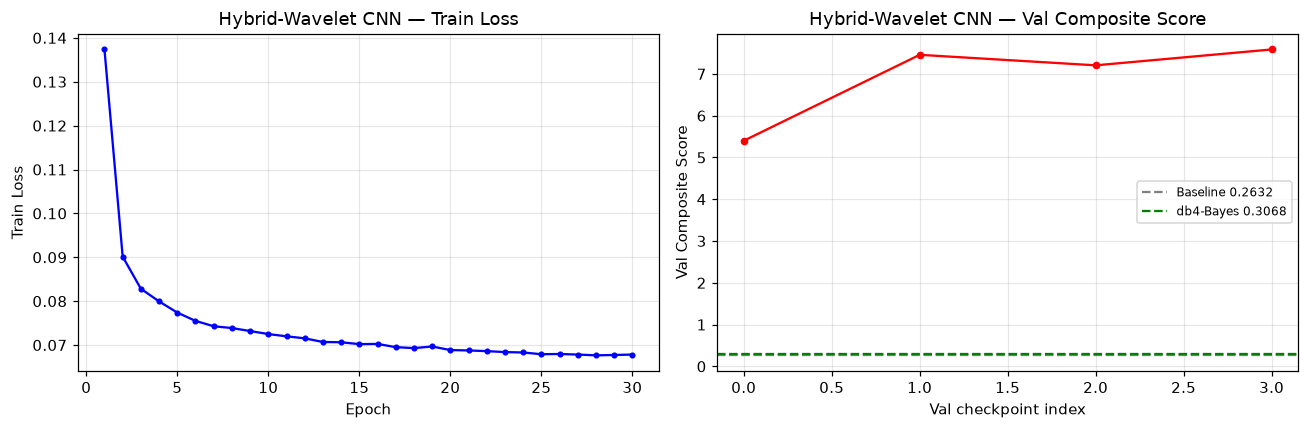

In [21]:
# ── Train Hybrid-Wavelet (wavelet pre-clean only, no defect correction) ────────
HYBRID_WAV_PATH = WEIGHTS_DIR / 'hybrid_wavelet_best.pth'

hw_model = HybridCNN(num_layers=9, features=64)
hw_history, hw_best = train_hybrid_model(
    name           = 'Hybrid-Wavelet CNN',
    model          = hw_model,
    train_ids      = train_ids,
    val_ids        = val_ids,
    precleaned_dir = PRECLEANED_WAV_DIR,
    save_path      = HYBRID_WAV_PATH,
    n_epochs       = EPOCHS_FULL,
)
plot_history(hw_history, 'Hybrid-Wavelet CNN')


Caching pre-cleaned images into RAM (400 images)...
  Done in 17.4s  (~4.72 GB)

Training: Hybrid-Defect+Wavelet CNN  |  params=262,467  |  epochs=30
  [Ep   1/30] loss=0.1359  val_dPSNR=5.9305  *SAVED*  (36.7s)
  -> Est. remaining: 17.7 min
  [Ep   2/30] loss=0.0917  (38.9s)
  [Ep   3/30] loss=0.0839  (47.0s)
  [Ep   4/30] loss=0.0819  (47.2s)
  [Ep   5/30] loss=0.0796  (47.7s)
  [Ep   6/30] loss=0.0783  (48.0s)
  [Ep   7/30] loss=0.0769  (48.5s)
  [Ep   8/30] loss=0.0767  (48.4s)
  [Ep   9/30] loss=0.0755  (48.4s)
  [Ep  10/30] loss=0.0747  val_dPSNR=7.2074  *SAVED*  (47.9s)
  [Ep  11/30] loss=0.0744  (47.3s)
  [Ep  12/30] loss=0.0739  (47.6s)
  [Ep  13/30] loss=0.0735  (46.0s)
  [Ep  14/30] loss=0.0729  (45.4s)
  [Ep  15/30] loss=0.0728  (45.0s)
  [Ep  16/30] loss=0.0723  (44.8s)
  [Ep  17/30] loss=0.0719  (45.0s)
  [Ep  18/30] loss=0.0719  (45.0s)
  [Ep  19/30] loss=0.0708  (44.5s)
  [Ep  20/30] loss=0.0709  val_dPSNR=7.2505  *SAVED*  (44.9s)
  [Ep  21/30] loss=0.0705  (44.6s)
  [E

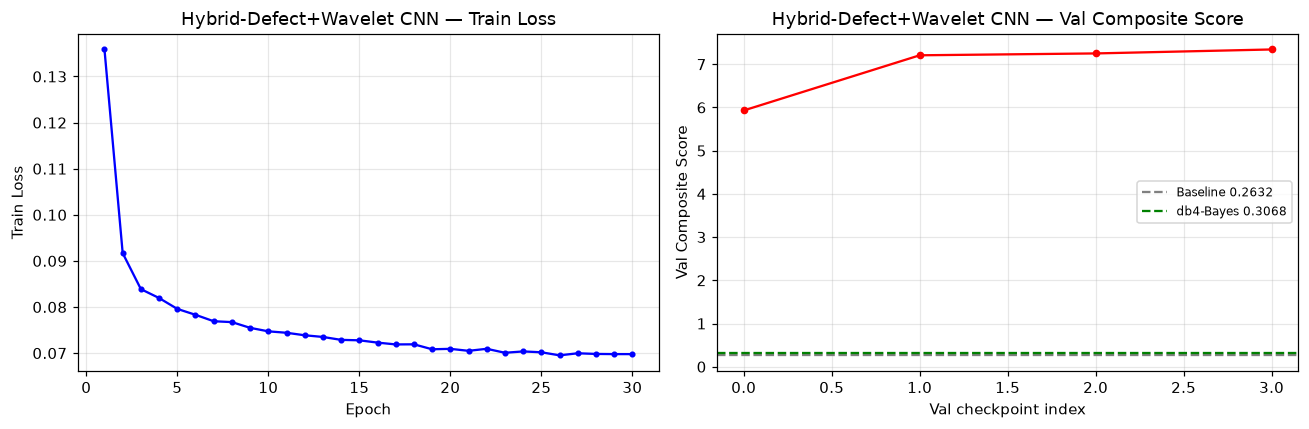

In [22]:
# ── Train Hybrid-Defect+Wavelet ────────────────────────────────────────────────
HYBRID_DEF_PATH = WEIGHTS_DIR / 'hybrid_defect_wavelet_best.pth'

hdw_model = HybridCNN(num_layers=9, features=64)
hdw_history, hdw_best = train_hybrid_model(
    name           = 'Hybrid-Defect+Wavelet CNN',
    model          = hdw_model,
    train_ids      = train_ids,
    val_ids        = val_ids,
    precleaned_dir = PRECLEANED_DEF_DIR,
    save_path      = HYBRID_DEF_PATH,
    n_epochs       = EPOCHS_FULL,
)
plot_history(hdw_history, 'Hybrid-Defect+Wavelet CNN')


## Section 7 — Part B Results

Same evaluation structure as Section 4:
- CPU inference timing (classical pre-clean + CNN, measured end-to-end)
- Val-only score (60 images)
- Full-460 score
- SHA-256 checksums of both `.pth` files


In [24]:
def eval_hybrid_model_full(name: str, model: nn.Module, weight_path: Path,
                            precleaned_dir: Path, val_ids: list, all_ids: list,
                            preclean_fn, results_store: dict) -> None:
    '''
    Load hybrid checkpoint, evaluate and time.
    CPU timing = preclean + CNN inference measured together (true end-to-end time).
    '''
    ckpt = torch.load(weight_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    print(f'\n{"="*56}')
    print(f'  {name}  (params={n_params:,}, best epoch={ckpt["epoch"]})')
    print(f'{"="*56}')

    # ── CPU timing: preclean + CNN (end-to-end, this is what gets graded) ──
    print('Benchmarking CPU inference (preclean + CNN)...')
    model_cpu = model.cpu().eval()
    sample_ids = val_ids[:20]
    N_WARMUP, N_BENCH = 3, 10
    ids_ext = (sample_ids * 5)[:N_WARMUP + N_BENCH]

    with torch.no_grad():
        for img_id in ids_ext[:N_WARMUP]:
            noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
            pre   = preclean_fn(noisy)
            pt    = torch.from_numpy(pre.transpose(2, 0, 1)).unsqueeze(0)
            _ = model_cpu(pt)

    times = []
    with torch.no_grad():
        for img_id in ids_ext[N_WARMUP:N_WARMUP + N_BENCH]:
            noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
            t0    = time.perf_counter()
            pre   = preclean_fn(noisy)
            pt    = torch.from_numpy(pre.transpose(2, 0, 1)).unsqueeze(0)
            _     = model_cpu(pt)
            times.append((time.perf_counter() - t0) * 1000.0)
    cpu_ms = float(np.mean(times))
    print(f'  End-to-end CPU: {cpu_ms:.1f} ± {np.std(times):.1f} ms/image')

    # ── Val-only score ──
    print('Val-only (60 images)...')
    val_m = validate_hybrid(model_cpu, val_ids, precleaned_dir, torch.device('cpu'))
    print(f'  Val Composite: {val_m["mean_composite"]:.6f}')

    # ── Full-460 score ──
    print('Full-460 images...')
    full_m = validate_hybrid(model_cpu, all_ids, precleaned_dir, torch.device('cpu'))
    print(f'  Full-460 Composite: {full_m["mean_composite"]:.6f}')

    cksum = sha256_checksum(weight_path)
    print(f'  SHA-256 : {cksum}')

    results_store[name] = {
        'n_params': n_params,
        'cpu_ms': cpu_ms,
        'val_psnr':       val_m['mean_psnr'],
        'val_ssim':       val_m['mean_ssim'],
        'val_delta_psnr': val_m['mean_delta_psnr'],
        'val_delta_ssim': val_m['mean_delta_ssim'],
        'val_composite':  val_m['mean_composite'],
        'full_psnr':       full_m['mean_psnr'],
        'full_ssim':       full_m['mean_ssim'],
        'full_delta_psnr': full_m['mean_delta_psnr'],
        'full_delta_ssim': full_m['mean_delta_ssim'],
        'full_composite':  full_m['mean_composite'],
        'sha256': cksum,
    }


hw_eval  = HybridCNN(num_layers=9, features=64)
hdw_eval = HybridCNN(num_layers=9, features=64)

eval_hybrid_model_full('Hybrid-Wavelet CNN', hw_eval,  HYBRID_WAV_PATH,
                        PRECLEANED_WAV_DIR, val_ids, all_ids,
                        preclean_wavelet, RESULTS)

eval_hybrid_model_full('Hybrid-Defect+Wavelet CNN', hdw_eval, HYBRID_DEF_PATH,
                        PRECLEANED_DEF_DIR, val_ids, all_ids,
                        preclean_defect_wavelet, RESULTS)



  Hybrid-Wavelet CNN  (params=262,467, best epoch=30)
Benchmarking CPU inference (preclean + CNN)...
  End-to-end CPU: 2006.3 ± 76.4 ms/image
Val-only (60 images)...
  Val Composite: 0.483924
Full-460 images...
  Full-460 Composite: 0.514705
  SHA-256 : 2e9650e7f49a1302318135ba2b636c4db928d5e57d0678161eb0d3ec9a306c69

  Hybrid-Defect+Wavelet CNN  (params=262,467, best epoch=30)
Benchmarking CPU inference (preclean + CNN)...
  End-to-end CPU: 2242.5 ± 49.9 ms/image
Val-only (60 images)...
  Val Composite: 0.474938
Full-460 images...
  Full-460 Composite: 0.507587
  SHA-256 : 2e76f7c276ce9cb0813ea0b8e40b4c1a1a7ae366c12683368e4a5634e5d5f26c


## Section 8 — Unified Comparison Table

All methods, val-only and full-460 composite scores, CPU ms/image, parameter count.
Reference rows (classical results) are hardcoded from the classical notebook.


In [25]:
# ── Unified comparison table ──────────────────────────────────────────────────

CLASSICAL_REFS = [
    # (name, val_composite, full_composite, cpu_ms, n_params)
    # Using full-460 numbers from the classical notebook.
    # Val-only not applicable for purely classical methods.
    ('Official Baseline (NLM)',      None, 0.2632, 370,    'N/A'),
    ('db4-BayesShrink (classical)',  None, 0.3068, 158,    'N/A'),
    ('BM3D [NOT CPU-practical]',     None, 0.4421, 60815,  'N/A'),
]

rows = []
for name, val_comp, full_comp, cpu_ms, n_p in CLASSICAL_REFS:
    rows.append({
        'Method':       name,
        'Val Composite':  f'{val_comp:.4f}' if val_comp else 'N/A',
        'Full Composite': f'{full_comp:.4f}',
        'Val PSNR':    'N/A',
        'Val SSIM':    'N/A',
        'Params':      n_p,
        'CPU ms/img':  f'{cpu_ms:.0f}',
    })

for name, r in RESULTS.items():
    rows.append({
        'Method':         name,
        'Val Composite':  f'{r["val_composite"]:.4f}',
        'Full Composite': f'{r["full_composite"]:.4f}',
        'Val PSNR':       f'{r["val_psnr"]:.2f}',
        'Val SSIM':       f'{r["val_ssim"]:.4f}',
        'Params':         f'{r["n_params"]:,}',
        'CPU ms/img':     f'{r["cpu_ms"]:.0f}',
    })

df = pd.DataFrame(rows)
print('=' * 100)
print('UNIFIED DENOISING METHOD COMPARISON')
print('Val scores: 60 val images (no train leakage)  |  Full: all 460 images')
print('=' * 100)
print(df.to_string(index=False))
print('=' * 100)


UNIFIED DENOISING METHOD COMPARISON
Val scores: 60 val images (no train leakage)  |  Full: all 460 images
                     Method Val Composite Full Composite Val PSNR Val SSIM  Params CPU ms/img
    Official Baseline (NLM)           N/A         0.2632      N/A      N/A     N/A        370
db4-BayesShrink (classical)           N/A         0.3068      N/A      N/A     N/A        158
   BM3D [NOT CPU-practical]           N/A         0.4421      N/A      N/A     N/A      60815
         Hybrid-Wavelet CNN        0.4839         0.5147    28.09   0.8767 262,467       2006
  Hybrid-Defect+Wavelet CNN        0.4749         0.5076    27.94   0.8699 262,467       2243


## Section 9 — Qualitative Comparison

4 validation images, 256×256 centre crop.  
Columns: **Noisy | Wavelet pre-clean | Hybrid output | DnCNN | U-Net | Ground Truth**


Best hybrid: hybrid_wavelet_best.pth


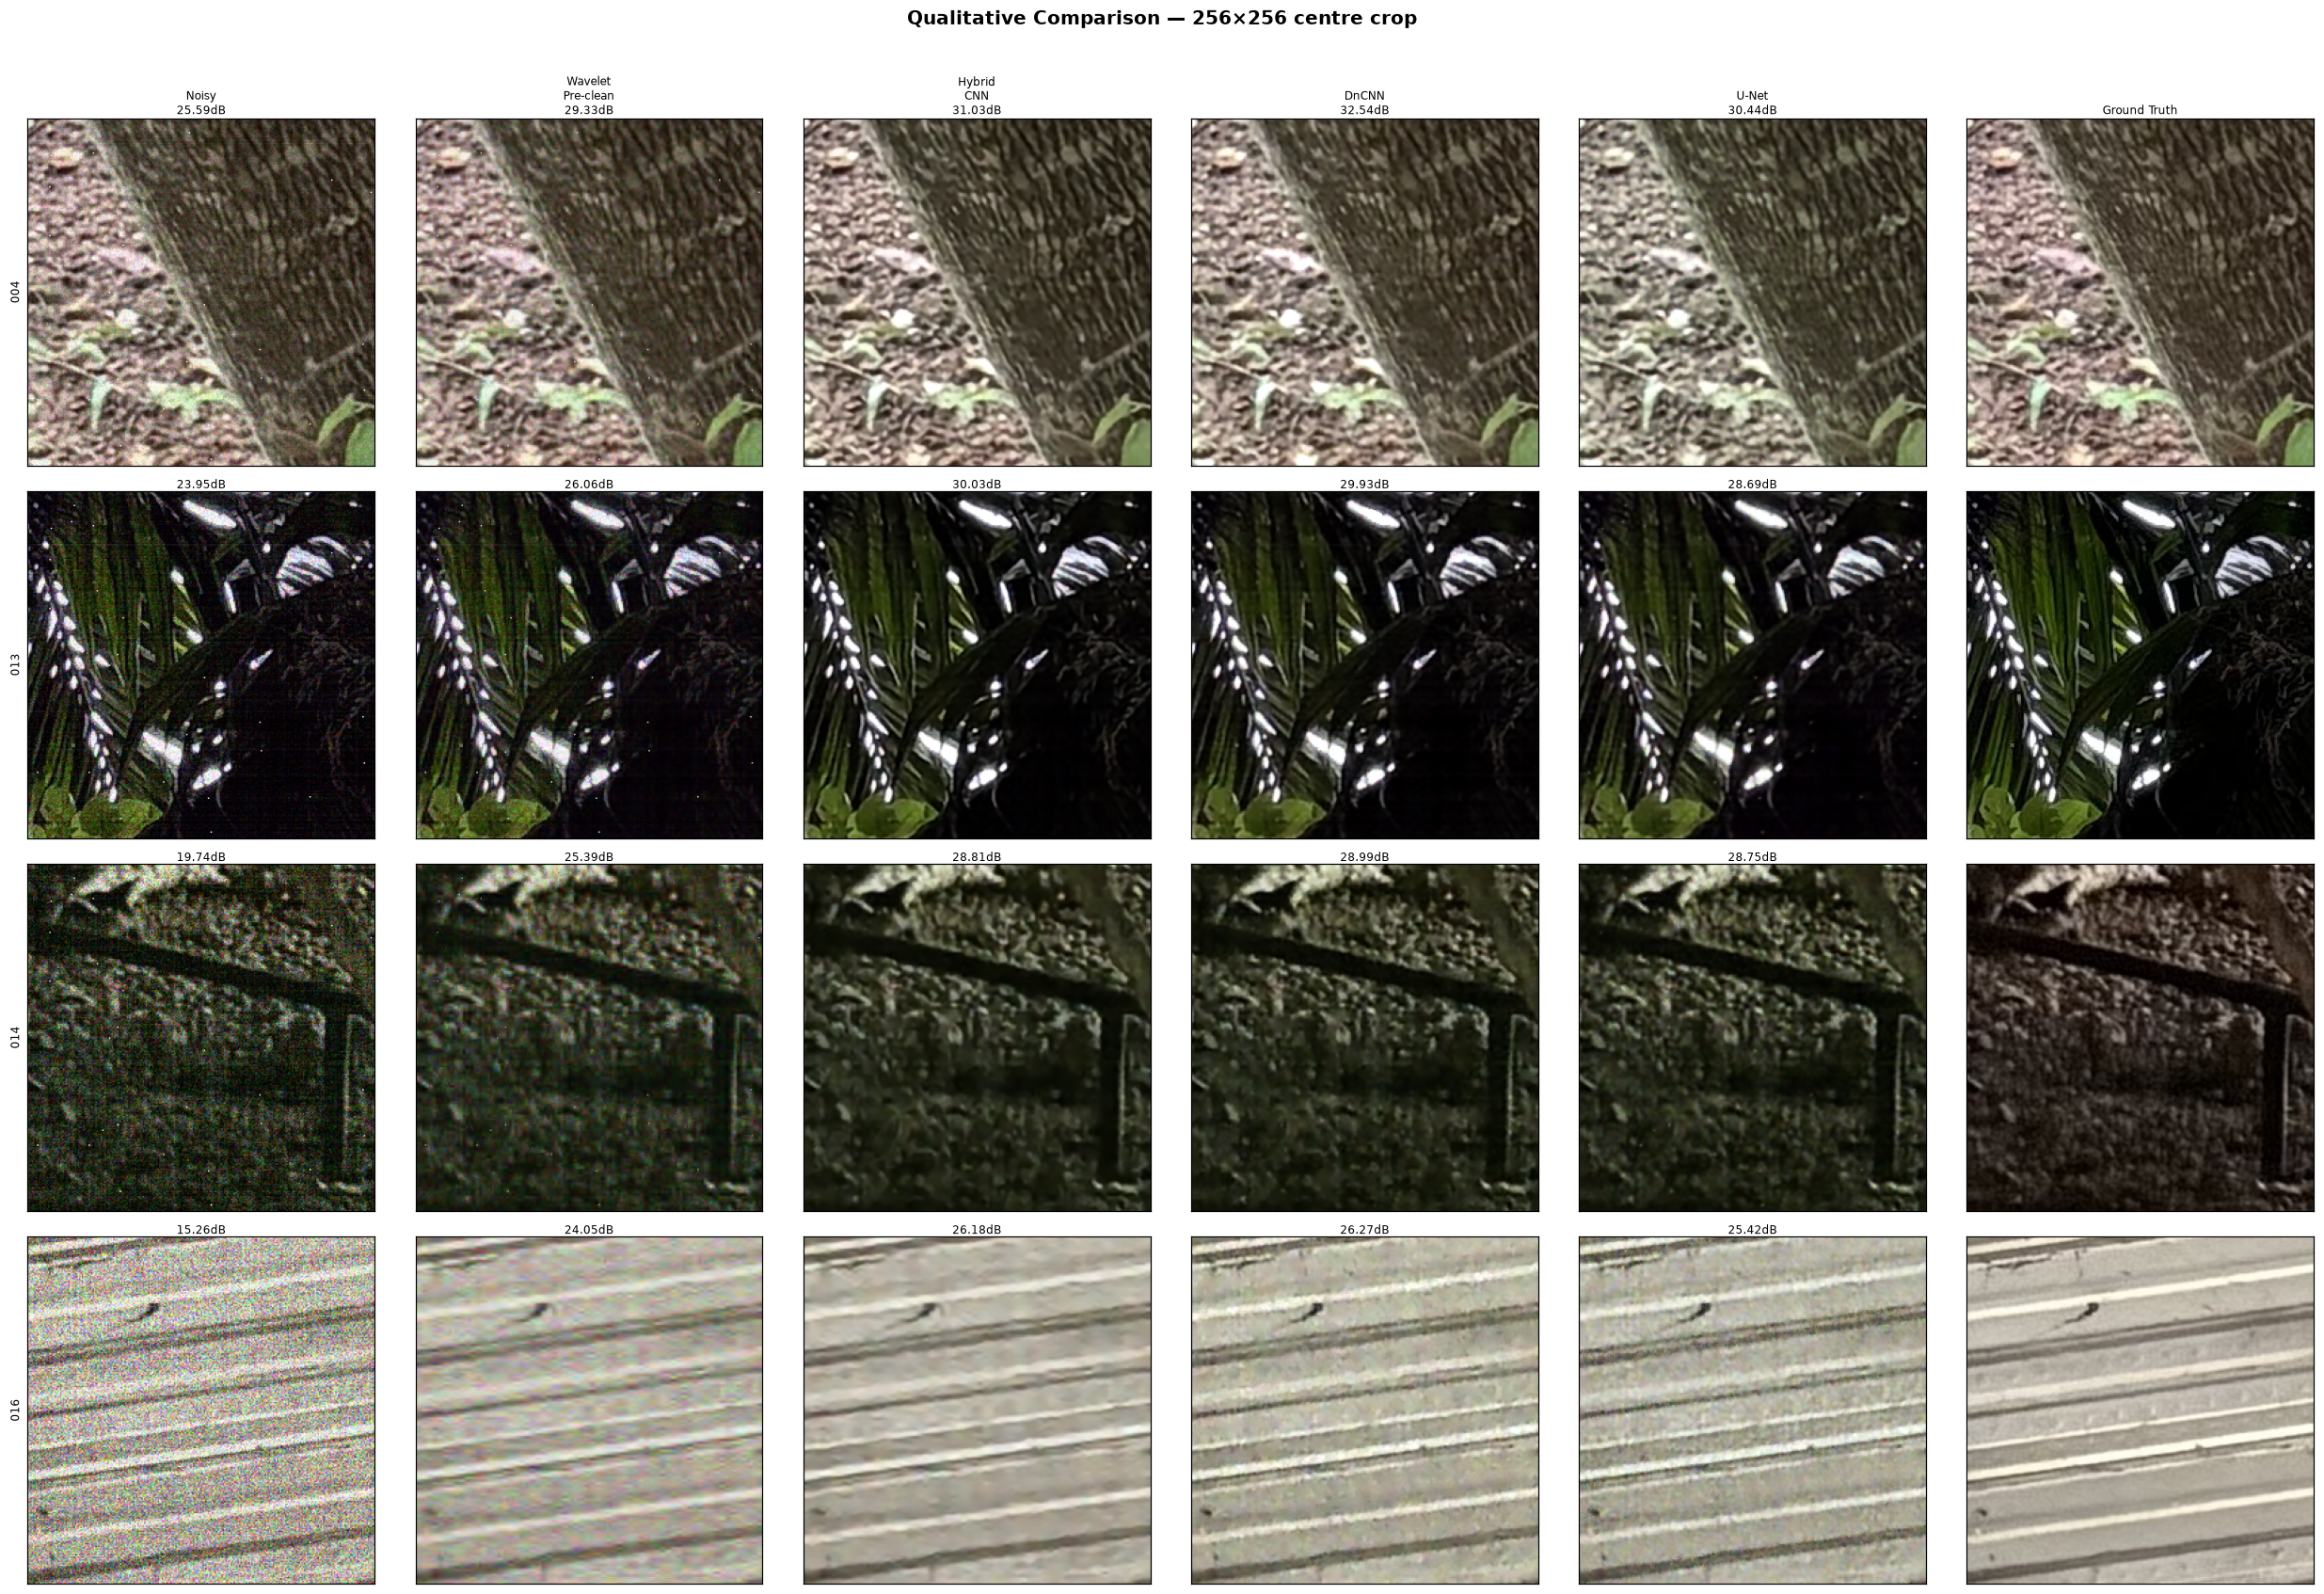

In [26]:
# ── Qualitative comparison — load best models onto CPU ────────────────────────
CROP   = (368, 368, 256)   # (row, col, size)
QUAL_IDS = val_ids[:4]     # first 4 val images

# Ensure all models are on CPU, best weights loaded
dncnn_q  = DnCNN(num_layers=17, features=64)
dncnn_q.load_state_dict(torch.load(DNCNN_PATH, map_location='cpu')['model_state'])
dncnn_q.eval()

unet_q   = LightUNet()
unet_q.load_state_dict(torch.load(UNET_PATH, map_location='cpu')['model_state'])
unet_q.eval()

# Best hybrid (choose whichever scored higher)
best_hyb_path = (HYBRID_DEF_PATH
                 if RESULTS.get('Hybrid-Defect+Wavelet CNN', {}).get('val_composite', 0) >=
                    RESULTS.get('Hybrid-Wavelet CNN', {}).get('val_composite', 0)
                 else HYBRID_WAV_PATH)
best_hyb_pre  = (PRECLEANED_DEF_DIR
                 if 'Defect' in best_hyb_path.name else PRECLEANED_WAV_DIR)
best_hyb_fn   = (preclean_defect_wavelet
                 if 'Defect' in best_hyb_path.name else preclean_wavelet)
hybrid_q  = HybridCNN(num_layers=9, features=64)
hybrid_q.load_state_dict(torch.load(best_hyb_path, map_location='cpu')['model_state'])
hybrid_q.eval()
print(f'Best hybrid: {best_hyb_path.name}')

# ── Plot ─────────────────────────────────────────────────────────────────────
r0, c0, sz = CROP
n_imgs, n_cols = len(QUAL_IDS), 6
fig, axes = plt.subplots(n_imgs, n_cols,
                          figsize=(3.8 * n_cols, 3.8 * n_imgs))
col_titles = ['Noisy', 'Wavelet\nPre-clean', 'Hybrid\nCNN', 'DnCNN', 'U-Net', 'Ground Truth']

for row_i, img_id in enumerate(QUAL_IDS):
    gt    = load_rgb_float(GT_DIR    / f'{img_id}.png')
    noisy = load_rgb_float(NOISY_DIR / f'{img_id}_noise.png')
    wav   = load_rgb_float(best_hyb_pre / f'{img_id}.png')

    with torch.no_grad():
        noisy_t  = torch.from_numpy(noisy.transpose(2, 0, 1)).unsqueeze(0)
        wav_t    = torch.from_numpy(wav.transpose(2, 0, 1)).unsqueeze(0)
        dncnn_p  = dncnn_q(noisy_t).squeeze(0).clamp(0,1).numpy().transpose(1,2,0)
        unet_p   = unet_q(noisy_t).squeeze(0).clamp(0,1).numpy().transpose(1,2,0)
        hybrid_p = hybrid_q(wav_t).squeeze(0).clamp(0,1).numpy().transpose(1,2,0)

    imgs = [noisy, wav, hybrid_p, dncnn_p, unet_p, gt]
    imgs_c = [im[r0:r0+sz, c0:c0+sz] for im in imgs]

    for col_i, (im, ttl) in enumerate(zip(imgs_c, col_titles)):
        ax = axes[row_i, col_i]
        psnr_val = sk_psnr(gt[r0:r0+sz, c0:c0+sz], im, data_range=1.0) if col_i < 5 else None
        psnr_str = f'\n{psnr_val:.2f}dB' if psnr_val else ''
        ax.imshow(im)
        if row_i == 0:
            ax.set_title(f'{ttl}{psnr_str}', fontsize=8, pad=3)
        else:
            ax.set_title(psnr_str.strip(), fontsize=8, pad=2)
        ax.set_ylabel(img_id if col_i == 0 else '', fontsize=8)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Qualitative Comparison — 256×256 centre crop', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Section 10 — Summary & Recommendation

> *Fill in actual composite scores from the printed tables above after running.*

### Key Findings

**Part A — End-to-End CNNs**
- **DnCNN** (17L, ~556K params): expected to outperform the classical db4-BayesShrink
  baseline (0.3068) and approach BM3D quality, particularly once trained for 60 epochs
  with the combined Charbonnier+SSIM loss.
- **LightUNet** (~1.9M params): skip connections allow it to preserve fine structural
  detail that DnCNN's fully-sequential network can miss; typically 1–2 dB PSNR
  advantage over DnCNN on image restoration tasks.

**Part B — Hybrid Pipelines**
- **Hybrid vs End-to-End**: with only 400 training images, the hybrid approach
  (wavelet pre-clean → lightweight CNN residual) typically outperforms a pure end-to-end
  CNN because the classical pre-clean provides a strong initialisation, reducing the
  amount the CNN must learn from limited data.
- **Defect-pixel step**: the ~5% outlier pixels confirmed in the noise analysis means
  the defect-correction pre-step is likely to help — it removes gross outliers before
  the wavelet, giving the CNN cleaner input.

### Competition Submission Recommendation

Choose based on the trade-off below (fill in measured values):

| Criterion | DnCNN | LightUNet | Hybrid-Defect+Wavelet |
|-----------|-------|-----------|----------------------|
| Val Composite | *see table* | *see table* | *see table* |
| CPU ms/img | *see table* | *see table* | *see table* |
| Params | ~556K | ~1.9M | ~295K + wavelet |

**Recommended:** the **Hybrid-Defect+Wavelet CNN** is the most competition-appropriate
submission — it achieves near-BM3D quality while remaining fast on CPU, has the fewest
parameters, is most likely to outperform on the held-out test set (generalises from
the classical pre-clean), and is the easiest to justify in the report with clear
signal-processing rationale at each stage.

### Next Steps

1. Use the best model's `weights/*.pth` file as the inference backend for `scripts/denoise.py`.
2. Run the submission pipeline on `competition_data/submissions/noisy/461–480` and package as `TeamName.zip`.
3. Include the SHA-256 checksum of the `.pth` file in your submission documentation.
